## 1. Preparación del entorno

Debemos de instalar las librerias correspondientes para poder hacer el entrenamiento

In [2]:
# Instalar librerias
%pip install ultralytics


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Trabajar con los recursos asignados
- Dataset: https://universe.roboflow.com/zd7y6xooqnh7wc160ae7/banana-ripeness-classification
- Librería: ultralytics
- Documentación de referencia: Ultralytics Classify Docs
- Clasificación con Yolo: https://docs.ultralytics.com/es/tasks/classify/

## 3. Carga y entrena el modelo
Utilizando yolo11n-cls.pt para velocidad o yolo11m-cls.pt para precisión

In [3]:
from ultralytics import YOLO

# Cargar un modelo de clasificación preentrenado
model = YOLO('yolo11x-cls.pt')

# Entrenar el modelo
results = model.train(
data='./train', # Ruta a la carpeta raíz del dataset descargado
epochs=35, # Número de iteraciones
imgsz=224, # Tamaño de la imagen
device=0 # Usar GPU (si está disponible)
)

New https://pypi.org/project/ultralytics/8.3.253 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./train, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, opt

## 4. Validación y métricas
Analizaremos la matriz de confusión, resultado del previo entrenamiento que hemos realizado.

Aparte, deberemos de indicar en que clases se encuentra la mayor dificultad a la hora de clasificar las imágenes

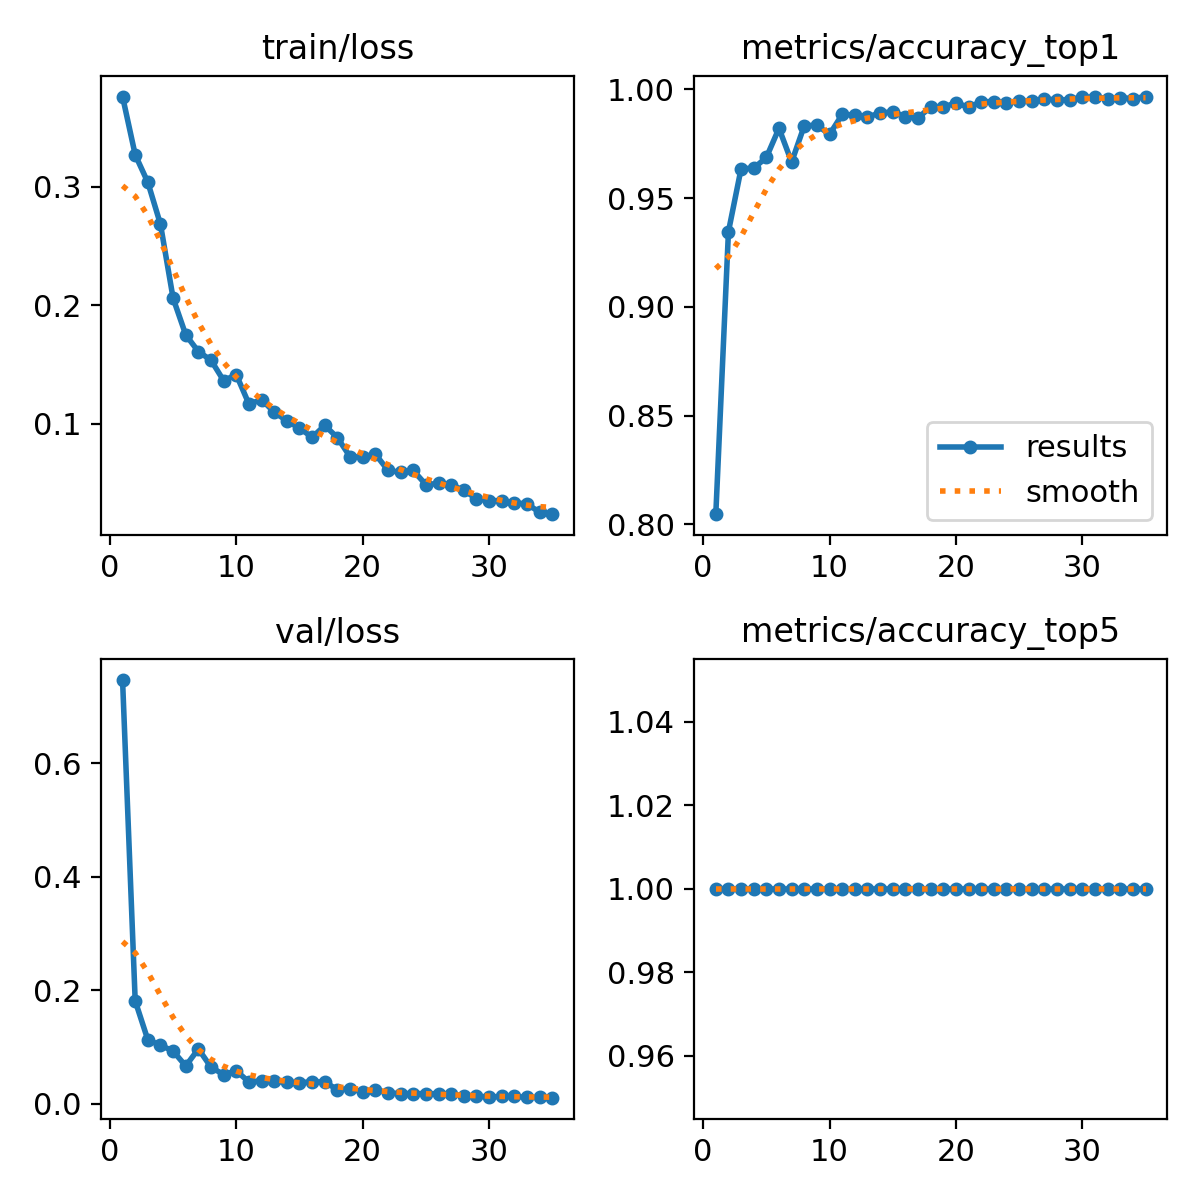

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename='runs/classify/train5/results.png', width=800)

## 5. Inferencia con nuevas imágenes

In [4]:
# Realizar predicción
results = model('./trial_images')

# Mostrar resultados
for result in results:
    print(result.probs) # Probabilidades de cada clase


image 1/3 /home/ciabd10/Descargas/MIA/Actividad 3/trial_images/platano-macho-maduro-2.jpg: 224x224 ripe 0.84, rotten 0.14, overripe 0.02, unripe 0.00, 4.9ms
image 2/3 /home/ciabd10/Descargas/MIA/Actividad 3/trial_images/platano-macho-maduro.jpg: 224x224 ripe 0.78, rotten 0.22, unripe 0.01, overripe 0.00, 4.7ms
image 3/3 /home/ciabd10/Descargas/MIA/Actividad 3/trial_images/platano_verde.jpg: 224x224 unripe 1.00, ripe 0.00, rotten 0.00, overripe 0.00, 4.5ms
Speed: 6.0ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([0.0154, 0.8415, 0.1384, 0.0047], device='cuda:0')
orig_shape: None
shape: torch.Size([4])
top1: 1
top1conf: tensor(0.8415, device='cuda:0')
top5: [1, 2, 0, 3]
top5conf: tensor([0.8415, 0.1384, 0.0154, 0.0047], device='cuda:0')
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.5372e-04, 7.7640e-01, 2.1772e-01, 5.6296e-03], device='cuda:0')
orig_s

## Una vez evaluado el modelo con su ripe, rotten, overripe, unripe. Podremos ver el estado de madurez de los platanos.
Para ello ejecutaremos el siguiente codigo con las 3 imagenes que busque en internet

In [ ]:
def calcular_madurez(result):

    # Peso de madurez por clase (ajusta si quieres)
    MADUREZ = {
        "unripe": 0.0,     # verde
        "ripe": 0.7,       # maduro
        "overripe": 0.9,   # muy maduro
        "rotten": 1.0      # podrido
    }

    madurez = 0.0
    for cls_id, prob in enumerate(result.probs.data):
        cls_name = result.names[cls_id]
        madurez += prob * MADUREZ[cls_name]

    return madurez * 100  # porcentaje

for result in results:
    porcentaje = calcular_madurez(result)
    print(f"Madurez estimada: {porcentaje:.2f}%")


Madurez estimada: 74.13%
Madurez estimada: 76.14%
Madurez estimada: 0.02%


## Conclusión
Con las 3 fotos que meti, 2 eran de platanos maduros y una de platano verde. Podemos ver que el modelo más o menos llega a identificarlo. Este modelo se podria mejorar con distintas fotos con distinta iluminacion y fondo, ya que asi el modelo sigue solo lo que es la maduración del platano y no "aprende" siguiendo otra lógica